

## **Dataset Description**

This dataset contains transactional data from an online retail store, including customer purchases, product information, and transaction details.

The dataset is used to analyze customer ourchasing behavior and to build customer segmentation and recommendation models.


| Column | Description |
|--------|------------|
| InvoiceNo | Transaction ID. If it starts with "C", it indicates a cancelled transaction. |
| StockCode | Product identifier. Some codes may represent non-product items (e.g., postage). |
| Description | Product description. |
| Quantity | Number of items purchased. Negative values may indicate returns. |
| InvoiceDate | Date and time of the transaction. From 2010/12/01 to 2011/12/09|
| UnitPrice | Price per item. |
| CustomerID | Unique identifier for each customer. |
| Country | Customer's country. |







# ***Step 1: Setup and Initialization***

In [7]:
!pip install openpyxl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ***Step 2: Initial Data Analysis***

Afterward, I am going to gain a thorough understanding of the dataset before proceeding to the data cleaning and transformation stages.

First I will perform a preliminary analysis to understand the structure and types of data columns.

In [8]:
df = pd.read_excel('Online Retail.xlsx')
df.head(10)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


## **Inferences:**

The dataset consists of 541,909 entries and 8 columns. Here is a brief overview of each column:



*   **`InvoiceNo`**: This is an object data type column that contains the invoice number for each transaction. Each invoice number can represent multiple items purchased in a single transaction.

*   **`StockCode`**: An object data type column representing the product code for each item.

*   **`Description`**: This column, also an object data type, contains descriptions of the products. It has some missing values, with 540,455 non-null entries out of 541,909.

*   **`Quantity`**: This is an integer column indicating the quantity of products purchased in each transaction.

*   **`InvoiceDate`**: A datatime column that records the date and time of each transaction.

*   **`UnitPrice`**: A float column representing the unit price or each product.

*   **`CustomerID`**: A float column that contains the customer ID for each transaction. This column has a significant number of missing values, with only 406,829 non-null entries out of 541,909.

*   **`Country`**: An object column recording the country where each transaction took place.

From a preliminary overview, it seems that there are missing values in the `Description` and `CustomerID` columnns which need to be addressed. The `InvoiceDate` column is already in datatime format, which will faciliate further time series analysis. We also observe that a single customer can have multiple transactions as inferred from the repeated `CustomerID` in the initial rows.

The next steps would include deeper data cleaning and preprocessing to handle missing values, potentially erroreous data, and to create new features that can help in achieving the project goals.



## **Summary Statistics**

Now, I am going to generate summary statistics to gain initial insights into the data distribution:

In [10]:
# Summary statistics for numerical variables
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Quantity,541909.0,9.55225,-80995.0,1.0,3.0,10.0,80995.0,218.081158
InvoiceDate,541909,2011-07-04 13:34:57.156386048,2010-12-01 08:26:00,2011-03-28 11:34:00,2011-07-19 17:17:00,2011-10-19 11:27:00,2011-12-09 12:50:00,NaN
UnitPrice,541909.0,4.611114,-11062.06,1.25,2.08,4.13,38970.0,96.759853
CustomerID,406829.0,15287.69057,12346.0,13953.0,15152.0,16791.0,18287.0,1713.600303


In [11]:
# Summary statistics for categorical variables
df.describe(include = 'object').T

,count,unique,top,freq
InvoiceNo,541909,25900,573585,1114
StockCode,541909,4070,85123A,2313
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369
Country,541909,38,United Kingdom,495478


## **Inferences:**

1.  **`Quantity`**:

*   The average quantity of products in a transaction is approximately 9.55.

*   The quantity has a wide range, with a minimum value of -80995 and a maximum value of 80995. The negative values indicate returned or cancelled orders, which need to be handled appropriately.

*   The standard deviation is quite large, indicating a significant spread in the data. The presence of outliers is indicated by a large difference between the maximum and the 75th percentile values.


2.   **`UnitPrice`**:

*   The average unit price of the products is approximately 4.61.

*   The unit price also shows a wide range, from -11062.06 to 38970, which suggests the presence of errors or noise in the data, as negative prices don't make sense.

*   Similar to the Quantity column, the presence of outliers is indicated by a large difference between the maximum and the 75th percentile values.


3.  **`CustomerID`**:

*   There are 406829 non-null entries, indicating missing values in the dataset which need to be addressed.

*   The Customer IDs range from 12346 to 18287, helping in identifying unique customers.

4.  **`InvoiceNo`**:

*   There are 25900 unique invoice numbers, indicating 25900 seperate transactions.

*   The most frequent invoice number is 573585, appearing 1114 times, possibly representing a large transaction or an order with multiple items.

5.  **`StockCode`**:

*   There are 4070 unique stock codes representing different products.

*   The most frequent stock code is 85123A, appearing 2313 times in the dataset.

6.  **`Description`**:

*   There are 4223 unique product descriptions.

*   The most frequent product description is "WHITE HANGING HEART T-LIGHT HOLDER", appearing 2369 times.

*   There are some missing values in this column which need to be treated.

7.  **`Country`**:

*   The transactions come from 38 different countries, with a dominant majority of the transactions (approximately 91.4%) originating from the United Kingdom.







## ***Step 3: Data Cleaning & Transformation:***

This step encompasses a comprehensive cleaning and transformation process to refine the dataset. It includes addressing missing values, eliminating duplicate entries, correcting anomalies in product codes and descriptions, and other necessarry adjustments to prepare the data for in-depth analysis and modeling.

See if there is missing value.

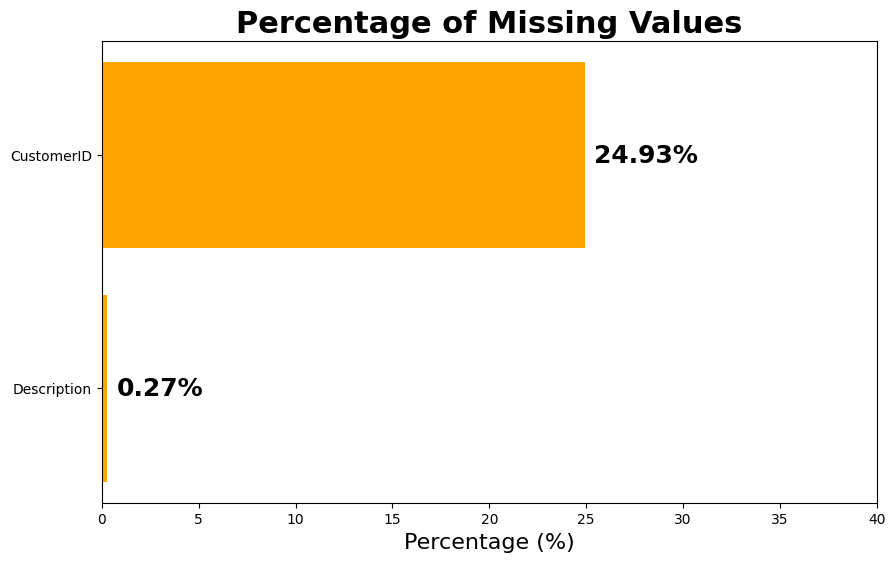

In [12]:
# Calculating the percentage of missing values for each column
missing_data = df.isnull().sum()
missing_percentage = (missing_data[missing_data > 0] / df.shape[0] * 100)

# Prepare values
missing_percentage.sort_values(ascending = True, inplace = True)

# Barh chart
fig, ax = plt.subplots(figsize = (10, 6))
ax,plt.barh(missing_percentage.index, missing_percentage, color = 'orange')

for i, (value, name) in enumerate(zip(missing_percentage, missing_percentage.index)):
  ax.text(value+0.5, i, f'{value:.2f}%', va = 'center', ha = 'left', fontweight = 'bold', fontsize = 18, color = 'black'
  )

# Set x-axis limit
ax.set_xlim([0, 40])

# Add title and xlabel
plt.title('Percentage of Missing Values', fontsize = 22, fontweight = 'bold')
plt.xlabel('Percentage (%)', fontsize = 16)
plt.show()

## **Handling Missing Values Strategy:**



1.   **CustomerID(24.93% missing values)**

*   The customerID column contains nearly a quarter of missing data. This column is essential for clustering customers and creating a recommendation system. Imputing such a large percentage of missing values might introduce significant bias or noise into the analysis.
*   Moreover, since the clustering is based on customer behavior and preferences, it's crucial to have accurate data on customer identifiers. Therefore, removing the rows with missing CustomerIDs seems to be the most reasonable approach to maintain the integrity of the clusters and the analysis.


2.   **Description(0.27% missing values)**


*   The Description column has a minor percentage of missing values. However, it has been noticed that there are inconsistencies in the data where the same StockCode does not always have the same Description. This indicates data quality issues and potential errors in the product descriptions.
*   Given these inconsistences, imputing the missing Descriptions based on StockCode might not be reliable, Moreover, since the missing percentage is quite low, it would be prudent to remove the rows with missing Desciptions to avoid propagating errors and inconsistencies into the subsequent analyses.

By removing rows with missing values in the CustomerID and Description columns,we aim to construct a cleaner and more reliable dataset, which is essential for achieving accurate clustering and creating an effective recommendation system.
















In [13]:
# Extracting rows with missing values in CustomerID or Description columns
df[df['CustomerID'].isnull()| df['Description'].isnull()].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,NaN,United Kingdom


In [14]:
# Removing rows with missing values in CustomerID and Description columns
df = df.dropna(subset = ['CustomerID', 'Description'])

In [15]:
# Verifying the removal of missing values
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


Next step, we are going to recognize duplicate rows in the dataset:

In [16]:
# Find duplicate rows
duplicate_rows = df[df.duplicated()]

# Sort the data by certain columns to see the duplicate rows next to each other
duplicate_rows_sorted = duplicate_rows.sort_values(by = ['InvoiceNo', 'StockCode', 'Description', 'CustomerID', 'Quantity'])

duplicate_rows_sorted.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
598,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.65,17920.0,United Kingdom
601,536412,21448,12 DAISY PEGS IN WOOD BOX,2,2010-12-01 11:49:00,1.65,17920.0,United Kingdom
604,536412,21448,12 DAISY PEGS IN WOOD BOX,2,2010-12-01 11:49:00,1.65,17920.0,United Kingdom
618,536412,21706,FOLDING UMBRELLA RED/WHITE POLKADOT,1,2010-12-01 11:49:00,4.95,17920.0,United Kingdom
616,536412,21708,FOLDING UMBRELLA CREAM POLKADOT,1,2010-12-01 11:49:00,4.95,17920.0,United Kingdom
594,536412,22141,CHRISTMAS CRAFT TREE TOP ANGEL,1,2010-12-01 11:49:00,2.10,17920.0,United Kingdom


## **Handling Duplicates Strategy:**

Duplicate rows were identified in the dataset, indicating that some transactions may have been recorded more than once. Since these rows contain identical values across all fields, they are unlikely to represent actual repeated purchases and are more likely the result of data recording errors. Keeping such duplicates would lead to double counting and introduce noise into the analysis.
Therefore, these duplicate rows were removed to ensure a cleaner and more reliable dataset.

In [17]:
# Displaying the number of duplicate rows
print(f"The dataset contains {df.duplicated().sum()} duplicate rows that need to be removed.")

df.drop_duplicates(inplace = True)

The dataset contains 5225 duplicate rows that need to be removed.


In [18]:
# Getting the number of rows in the dataframe
df.shape[0]

401604

To refine our understanding of customer behavior and preferences, we need to take into account the transactions that were cancelled. Intially we will identify these transactions by filtering the rows where the InvoiceNo starts with "C". Subsequently, we will analyze these rows to understand their common characteristics or patterns:

In [19]:
# Filter out the rows with InvoiceNo starting with "C" and create a new column indicating the transaction status
df['TransactionStatus'] = np.where(df['InvoiceNo'].astype(str).str.startswith('C'), 'Cancelled', 'Completed')

# Analyze the characteristics of these rows (considering the new column)
Cancelled_transactions = df[df['TransactionStatus'] == 'Cancelled']
Cancelled_transactions.describe().drop('CustomerID', axis = 1)

,Quantity,InvoiceDate,UnitPrice
count,8872.000000,8872,8872.000000
mean,-30.774910,2011-06-27 09:06:05.024797184,18.899512
min,-80995.000000,2010-12-01 09:41:00,0.010000
25%,-6.000000,2011-03-23 11:23:45,1.450000
50%,-2.000000,2011-07-11 13:51:00,2.950000
75%,-1.000000,2011-10-06 20:36:00,4.950000
max,-1.000000,2011-12-09 11:58:00,38970.000000
std,1172.249902,NaN,445.190864


In [ ]:
# Filter out cancelled transactions from the main DataFrame
df = df[df['TransactionStatus'] == 'Completed']

# Drop the 'TransactionStatus' column as it's no longer needed in the main DataFrame
df = df.drop(columns=['TransactionStatus'])

print("Cancelled transactions removed. Displaying the first few rows of the updated DataFrame:")
display(df.head())

In [ ]:
# Verify the number of rows after removal
print(f"Number of rows after removing cancelled transactions: {df.shape[0]}")

**Inferences from the Cancelled Transactions Data:**
*   All quantities in the cancelled transactions are negative, indicating that these are indeed orders thwat were cancelled.
*   The UnitPrice column has a considerable spread, showing that a variety of products, from low to high value, were part of the cancelled transactions.




**Strategy for Handling Cancelled Transactions:**

Cancelled transactions were identified based on InvoiceNo starting with "C" and were excluded from the main dataset. Since these records do not represent actual completed purchases, including then would distort key metrics such as purchase frequency and monetary value.
Therefore, only completed transactions were retained to ensure accurate customer segmentation and recommendation modeling.

First of all, let's find the number of unique stock codes and to plot the top 10 most frequent stock codes along with their percentage frequency:

In [20]:
# Finding the number of unique stock codes
unique_stock_codes = df['StockCode'].nunique()

# Printing the number of unique stock codes
print(f"The number of unique stock codes in the dataset is: {unique_stock_codes}")

The number of unique stock codes in the dataset is: 3684


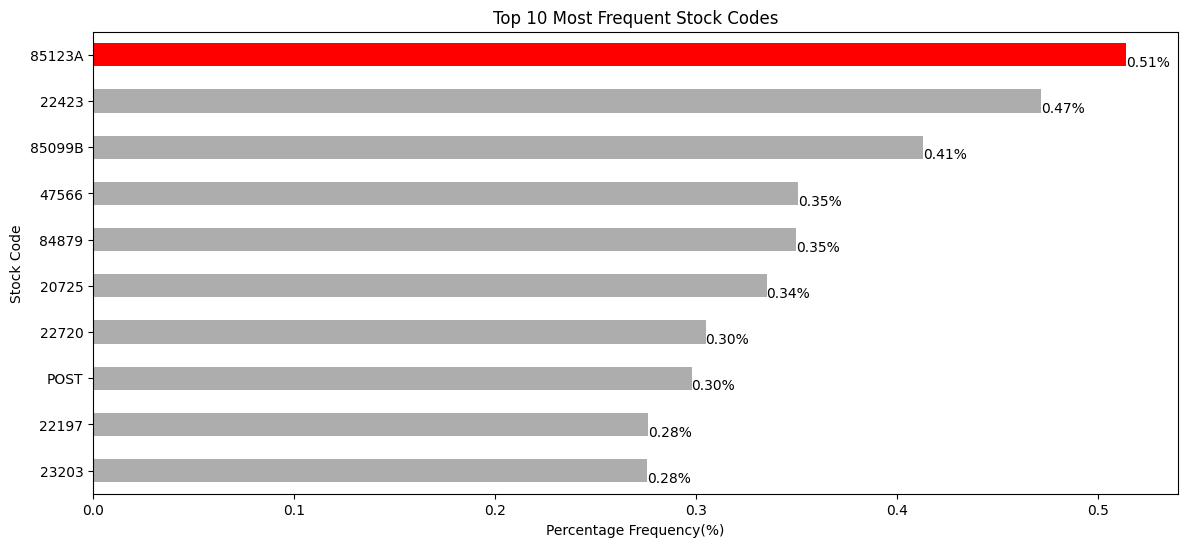

In [21]:
# Finding the top 10 most frequent stock codes
top_10_stock_codes = df['StockCode'].value_counts(normalize= True).head(10) * 100

top_10_stock_codes = top_10_stock_codes.sort_values(ascending = False)

colors = ['#ADADAD']*len(top_10_stock_codes)

max_index = top_10_stock_codes.argmax()
colors[max_index] = 'red'

# Plotting the top 10 most frequent stock codes
plt.figure(figsize = (14, 6))
top_10_stock_codes.plot(kind = 'barh', color = colors)

# Adding the percentage frequency on the bars
for index, value in enumerate(top_10_stock_codes):
  plt.text(value, index+0.25, f'{value:.2f}%', fontsize = 10)

plt.title('Top 10 Most Frequent Stock Codes')
plt.xlabel('Percentage Frequency(%)')
plt.ylabel('Stock Code')
plt.gca().invert_yaxis()
plt.show()

## **Inferences on Stock Codes**


*  **Product Variety**: The dataset contains 3684 unique stock codes, indicating a substantial variety of products available in the online retail store. This diversity can potentially lead to the identification of distinct customer clusters, with preferences for different types of products.

*  **Popular Items**: A closer look at the top 10 most frequent stock codes can offer insights into the popular products or categories that are frequently purchased by customers.

*  **Stock Code Anomalies**: We observe that while most stock codes are composed of 5 or 6 characters, there are some anomalies like the code '**POST**'. These anomalies might represent services or non-product transactions (perhaps postage fees) rather than actual products. To maintain the focus of the project, which is clustering based on product purchases and creating a recommendation system, these anomalies should be further investigated and possibly treated appropriately to ensure data integrity.



To delve into deeper into identifying these anomalies, let's explore the frequency of the number of numeric characters in the stock codes, which can provide insights into the nature of these unusual entries:

In [22]:
# Finding the number of numeric characters in each unique stock code
unique_stock_codes = df['StockCode'].unique()
numeric_char_counts_in_unique_codes = pd.Series(unique_stock_codes).apply(
    lambda x: sum(c.isdigit() for c in str(x))).value_counts()

# Printing the value counts for unique stock codes
print("Value counts of numeric character frequencies in unique stock codes:")
print("-"*70)
print(numeric_char_counts_in_unique_codes)

Value counts of numeric character frequencies in unique stock codes:
----------------------------------------------------------------------
5    3676
0       7
1       1
Name: count, dtype: int64


## **Inferences:**

The output indicates the following:


*   A majority of the unique stock codes (3678 out of 3684) contain exactly 5 numeric characters, which seems to be the standard format for representing product codes in this dataset.
*   There are a few anomalies: 7 stock codes contain no numeric characters and 1 stock code contains only 1 numeric character. These are clearly deviating from the standard format and need further investigation to understand their nature and whether they represent valid product transactions.

Now, let's identify the stock codes that contain 0 or 1 numeric characters to further understand these anomalies.



In [23]:
# Finding and printing the stock codes with 0 or 1 numeric characters
anomalous_stock_codes = [
    code for code in unique_stock_codes if sum(c.isdigit() for c in str(code)) in [0, 1]
]

# Printing each stock code on a new line
print("Anomalous stock codes:")
print("-"*22)
for code in anomalous_stock_codes:
  print(code)

Anomalous stock codes:
----------------------
POST
D
C2
M
BANK CHARGES
PADS
DOT
CRUK


Let's calculate the percentage of records with these anomalous stock codes:

In [24]:
# Calculating the percentage of records with these stock codes
percentage_anomalous = (df['StockCode'].isin(anomalous_stock_codes).sum() / len(df)) * 100

# Printing the percentage
print(f"The percentage of records with these anomalous stock codes in the dataset is: {percentage_anomalous:.2f}%")

The percentage of records with these anomalous stock codes in the dataset is: 0.48%


## **Inferences:**

Based on the analysis, we find that a very small proportion of the records, **0.48%**, have anomalous stock codes, which deviate from the typical format observed in the majority of the data. Also, these anomalous codes are just a fraction among all unique stock codes (**only 8 out of 3684**).

These codes seem to represent non-product transactions like "**BANK CHARGES**", "**POST**" (possibly postage fees), etc. Since they do not represent actual products and are a very small proportion of the dataset, including them in the analysis might introduce noise and distort the clustering and recommendation system.

## **Strategy:**

Given the context of the project, where the aim is to cluster customers based on their product purchasing behaviors and develop a product recommendation system, it would be prudent to exclude these records with anomalous stock codes from the dataset. This way, the focus remains strictly on genuine product transactions, which would lead to a more accurate and meaningful analysis.


Thus, the strategy would be to filter out and remove rows with these anomalous stock codes from ther dataset before proceeding with further analysis and model development.

In [25]:
# Removing rows with anomalous stock codes from the dataset
df = df[~df['StockCode'].isin(anomalous_stock_codes)]

In [26]:
# Getting the number of rows in the dataframe
df.shape[0]

399689

## **Cleaning Description Column**

First, I will calculate the occurrence count of each unique description in the dataset.

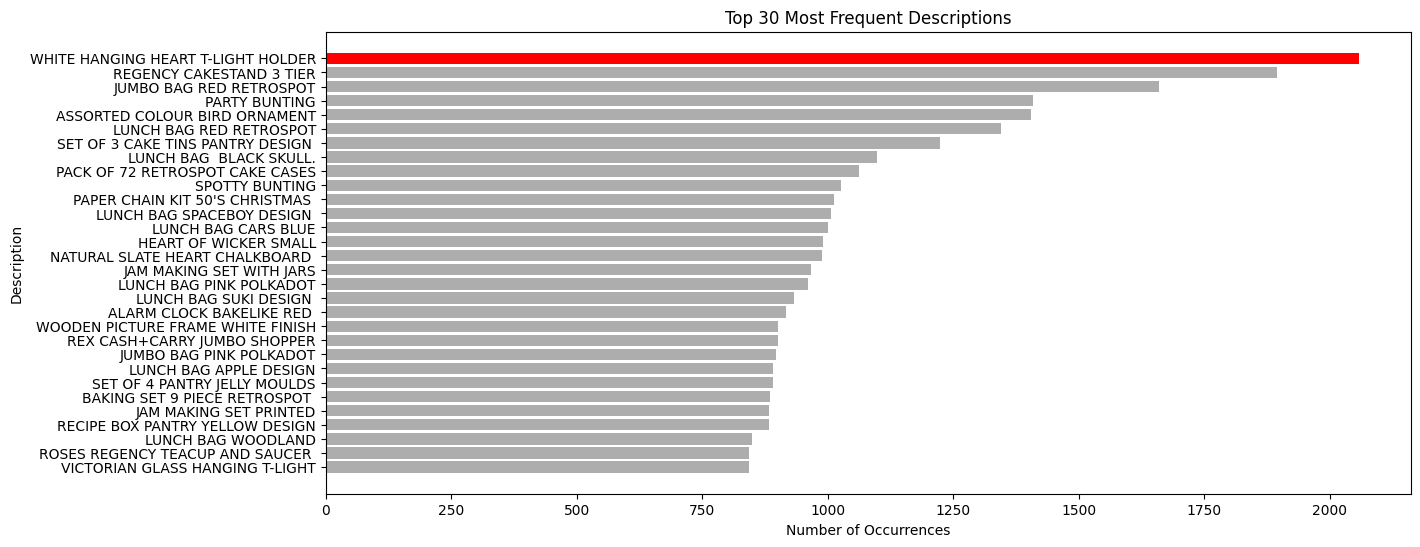

In [27]:
# Calculating the occurrence of each unique description and sort them
description_counts = df['Description'].value_counts()

# Get the top 30 descriptions
top_30_descriptions = description_counts[:30]

colors = ['#ADADAD']*len(top_30_descriptions)

max_index = top_30_descriptions.argmax()
colors[max_index] = 'red'

# Plotting
plt.figure(figsize = (14, 6))
plt.barh(top_30_descriptions.index[::1], top_30_descriptions.values[::1], color = colors)

# Adding labels and title
plt.xlabel('Number of Occurrences')
plt.ylabel('Description')
plt.title('Top 30 Most Frequent Descriptions')


plt.gca().invert_yaxis()
plt.show()


## **Inferences on Descriptions:**



*   The most frequent descriptions are generally household items, particularly those associated with kitchenware, lunch bags, and decorative itmes.

*   Interestingly, all the desciptions are in uppercase, which might be a standardized format for entering product descriptions in the database. However, considering the inconsistencies and anomalies encountered in the dataset so far, it would be prudent to check if there are descriptions entered in lowercase or a mix of case styles.



In [28]:
# Find unique descriptions containing lowercase characters
lowercase_descriptions = df['Description'].unique()
lowercase_descriptions = [desc for desc in lowercase_descriptions if any(char.islower() for char in desc)]

# Print the unique descriptions containing lowercase characters
print("The unique descriptions containing lowercase characters are:")
print("-"*60)
for desc in lowercase_descriptions:
  print(desc)

The unique descriptions containing lowercase characters are:
------------------------------------------------------------
BAG 500g SWIRLY MARBLES
POLYESTER FILLER PAD 45x45cm
POLYESTER FILLER PAD 45x30cm
POLYESTER FILLER PAD 40x40cm
FRENCH BLUE METAL DOOR SIGN No
BAG 250g SWIRLY MARBLES
BAG 125g SWIRLY MARBLES
3 TRADITIONAl BISCUIT CUTTERS  SET
NUMBER TILE COTTAGE GARDEN No
FOLK ART GREETING CARD,pack/12
ESSENTIAL BALM 3.5g TIN IN ENVELOPE
POLYESTER FILLER PAD 65CMx65CM
NUMBER TILE VINTAGE FONT No 
POLYESTER FILLER PAD 30CMx30CM
POLYESTER FILLER PAD 60x40cm
FLOWERS HANDBAG blue and orange
Next Day Carriage
THE KING GIFT BAG 25x24x12cm
High Resolution Image


Inference:



*   Upon reviewing the descriptions that contain lowercase characters, it is evident that some entries are not product descriptions, such as "**Next Day Carriage**" and "**High Resolution Image**". These entries seem to be unrelated to the actual products and might represent other types of information or service details.




## **Strategy:**


*   **Step 1**: Remove the rows where the descriptions contain service-related information like "**Next Day Carriage**" and "**High Resolution Image**", as these do not represent actual products and would not contribute to the clustering and recommendation system we aim to build.


*   **Step 2**: For the remaining descriptions with mixed case, standardized the text to uppercase to maintain uniformity across the dataset. This will also assist in reducing the chances of having duplicate entries with different case styles.

By implementing the above strategy, we can enhance the quality of our dataset, making it more suitable for the analysis and modeling phases of our project.



In [29]:
service_related_descriptions = ['Next Day Carriage', 'High Resolution Image']

# Calculate the percentage of records with service_related descriptions
service_related_percentage = df[df['Description'].isin(service_related_descriptions)].shape[0] / df.shape[0] * 100

# Print the percentage of records with service_related descriptions
print(f"The percentage of records with service-related descriptions in the dataset is: {service_related_percentage:.2f}%")

# Remove rows with service_related information in the description
df = df[~df['Description'].isin(service_related_descriptions)]

# Standardize the text to uppercase to maintain uniformity across the dataset
df['Description'] = df['Description'].str.upper()

The percentage of records with service-related descriptions in the dataset is: 0.02%


In [30]:
# Getting the number of rows in the dataframe
df.shape[0]

399606

## **Treating Zero Unit Prices**

In this step, first I am going to take a look at the statistical description of the UnitPrice column.

In [31]:
df['UnitPrice'].describe()

,UnitPrice
count,399606.000000
mean,2.904957
std,4.448796
min,0.000000
25%,1.250000
50%,1.950000
75%,3.750000
max,649.500000


## **Inference:**

The minimum unit price value is zero. This suggests that there are some transactions where the unit price is zero, potentially indicating a free item or a data entry error. To understand their nature, it is essential to investigate these zero unit price transactions further. A detailed analysis of the product descriptions associated with zero unit prices will be conducted to determine if they adhere to a specific pattern.

In [32]:
df[df['UnitPrice']==0].describe()[['Quantity']]

,Quantity
count,33.000000
mean,420.515152
min,1.000000
25%,2.000000
50%,11.000000
75%,36.000000
max,12540.000000
std,2176.713608


## **Inference on UnitPrice:**



*   The transactions with a unit price of zero are relatively few in number (33 transactions).

*   These transactions have a large variability in the quantity of items involved, ranging from 1 to 12540, with a substantial standard deviation.

*   Including these transactions in the clustering analysis might introduce noise and could potentially distort the customer behavior patterns identified by the clustering algorithm.


## **Strategy:**

Given the small number of these transactions and their potential to introduce noise in the data analysis, the strategy should be to remove these transactions from the dataset. This would help in maintaining a cleaner and more consistent dataset, which is essential for building an accurate and reliable clustering model and recommendation system.

In [33]:
# Removing records with a unit price of zero to avoid potential data enter errors
df = df[df['UnitPrice'] > 0]

## **Outlier Treatment**

In K-means clustering, the algorithm is sensitive to both the scale of data and the presence of outliers, as they can significantly influence the position of centroids, potentially leading to incorrect cluster assignments. However, considering the context of this project where the final goal is to understand customer behavior and preferences through K-means clustering, it would be more prudent to address the issue of outliers **after the feature engineering phase** where we create a customer-centric dataset. At this stage, the data us transactional, and removing outliers might eliminate valuable information that could play a crucial role in segmenting customers later on. Therefore, we will postpone the outlier treatment and proceed to the next stage for now.

In [34]:
# Resetting the index of the cleaned dataset
df.reset_index(drop = True, inplace = True)

In [35]:
df.shape[0]

399573

# ***Step 4: Feature Engineering***

In order to create a comprehensive customer-centric dataset for clustering and recommendation, the following features can be engineered from the available data.

## **RFM Features**

RFM is a method used for analyzing customer value and segmenting the customer base. It is an acronym that stands for:



*   **Recency (R)**: This metric indicates how recently a customer has made a purchase. A lower recency value means the customer has purchased more recently, indicating higher engagement with the brand.

*   **Frequency (F)**: This metric signifies how often a customer makes a purchase within a certain period. A higher frequency value indicates a customer who interacts with the business more often, suggesting higher loyalty or satisfaction.

*   **Monetary (M)**: This metric represents the total amount of money a customer has soent over a certain period. Customers who have a higher monetary value have contributed more to the business, indicating their potential high lifetime value.

Together, these metrics help in understanding a customer's buying behavior and preferences, which is pivotal in personalizing marketing strategies and creating a recommendation system.



## **Recency (R):**

In this step, we focus on understanding how recently a customer has made a purchase. This is a crucial aspect of customer segmentation as it helps in identifying the engagement level of customers. Here, I am going to define the following feature:



*   **Days Since Last Purchas**: This feature represents the number of days that hae passed since the customer's last purchase. A lower value indicates that the customer has purchased recently, implying a higher engagement level with the business, whereas a higher value may indicate a lapse or decreased engagement. By understanding the recency of purchases, businesses can tailor their marketing strategies to re-engage customers who have not made purchases in a while, potentially increasing customer retention and fostering loyalty.




In [36]:
# Convert InvoiceDate to datatime type
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Convert InvoiceDate to datatime and extract only the date
df['InvoiceDay'] = df['InvoiceDate'].dt.date

# Find the most recent purchases date for each customer
customer_data = df.groupby('CustomerID')['InvoiceDay'].max().reset_index()

# Find the most recent date in the entire dataset
most_recent_date = df['InvoiceDay'].max()

# Convert InvoiceDate to datatime type before subtraction
customer_data['InvoiceDay'] = pd.to_datetime(customer_data['InvoiceDay'])
most_recent_date = pd.to_datetime(most_recent_date)

# Calculate the number of days since the last purchases for each customer
customer_data['DaysSinceLastPurchase'] = (most_recent_date - customer_data['InvoiceDay']).dt.days

# Remove the InvoiceDay column
customer_data.drop('InvoiceDay', axis = 1, inplace = True)

Now, **customer_data** dataframe contains the **`Days_Since_Last_Purchases`** feature:



In [37]:
customer_data.head()

,CustomerID,DaysSinceLastPurchase
0,12346.0,325
1,12347.0,2
2,12348.0,75
3,12349.0,18
4,12350.0,310


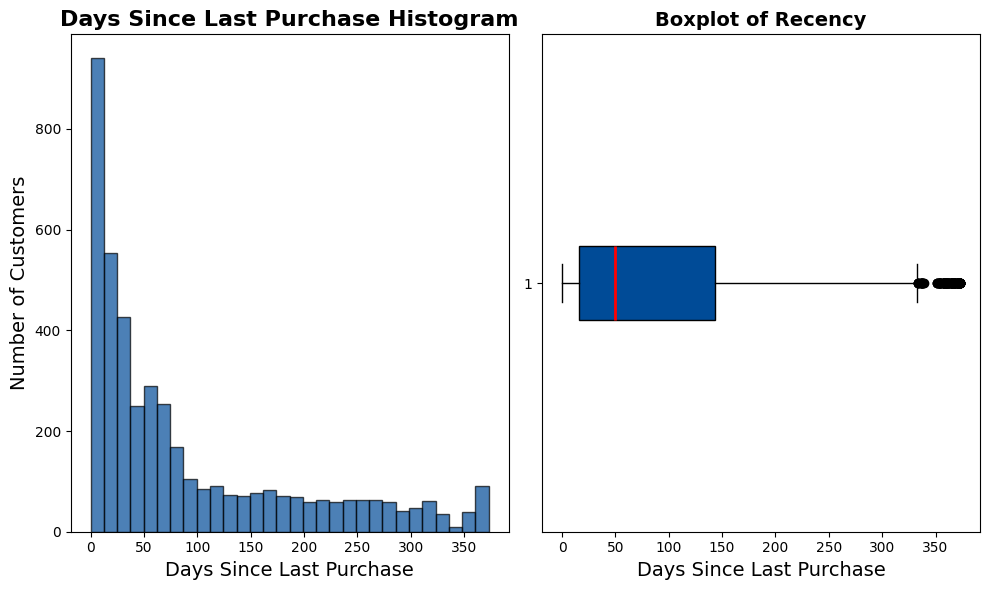

In [38]:
from types import FunctionType
fig, ax = plt.subplots(1, 2, figsize = (10, 6))

# Histogram
ax[0].hist(
    customer_data['DaysSinceLastPurchase'],
    bins = 30,
    color = '#004B97',
    edgecolor = 'black',
    alpha = 0.7
)

ax[0].set_title(
    'Days Since Last Purchase Histogram',
    fontsize = 16,
    fontweight = 'bold'
)

ax[0].set_xlabel('Days Since Last Purchase', fontsize = 14)
ax[0].set_ylabel('Number of Customers', fontsize = 14)

# Boxplot
ax[1].boxplot(
    customer_data['DaysSinceLastPurchase'],
    vert = False,
    patch_artist = True,
    boxprops = dict(facecolor = '#004B97', color = 'black'),
    medianprops = dict(color = 'red', linewidth = 2),
    whiskerprops = dict(color = 'black'),
    flierprops = dict(marker = 'o', markerfacecolor = 'black', markersize = 6)
)

ax[1].set_xlabel('Days Since Last Purchase', fontsize = 14)
ax[1].set_title('Boxplot of Recency', fontsize = 14, fontweight = 'bold')

plt.tight_layout()
plt.show()


Note:

*   I've named the customer-centric dataframe as **customer_data**, which will eventually contain all the customer-based features we plan to create.



# **Frequency (F)**

In this step, I am going to create two features that quantify the frequency of a customer's engagement with the retailer:



*   **Total Transactions**: This feature represents the total number of transactions made by a customer. It helps in understanding the engagement level of a customer with the retailer.

*   **Total Products Purchased**: This feature indicates the total number of products (sum of quantities) purchased by a customer across all transactions. It gives an insight into the customer's buying behavior in terms of the volume of products purchased.


These features will be crucial in segmenting customers based ob their buying frequency, which is a key aspect in determing customer segements for targeted marketing and personalized recommendations.



In [39]:
# Calculate the total number of transactions made by customer
total_transactions = df.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
total_transactions.rename(columns = {'InvoiceNo': 'Total_Transactions'}, inplace = True)

# Calculate the total number of products purchased by each customer
total_products_purchased = df.groupby('CustomerID')['Quantity'].sum().reset_index()
total_products_purchased.rename(columns = {'Quantity': 'Total_Products_Purchased'}, inplace = True)

# Merge the new features into the customer_data dataframe
customer_data = pd.merge(customer_data, total_transactions, on = 'CustomerID')
customer_data = pd.merge(customer_data, total_products_purchased, on = 'CustomerID')

# Display the first few rows of the customer_data dataframe
customer_data.head()

,CustomerID,DaysSinceLastPurchase,Total_Transactions,Total_Products_Purchased
0,12346.0,325,2,0
1,12347.0,2,7,2458
2,12348.0,75,4,2332
3,12349.0,18,1,630
4,12350.0,310,1,196


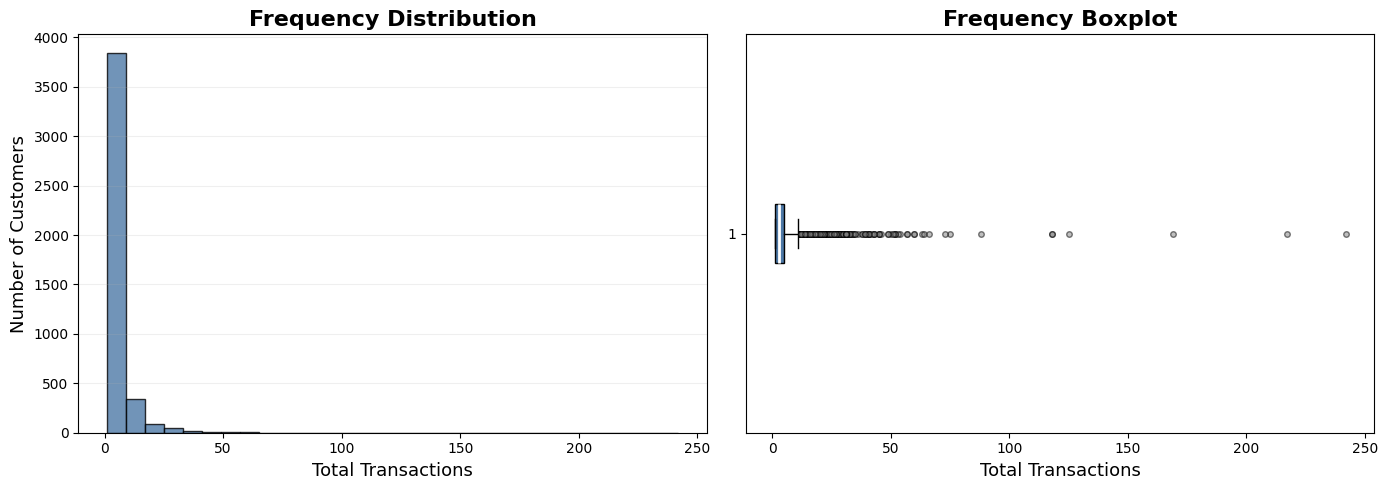

In [40]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax[0].hist(
    customer_data['Total_Transactions'],
    bins=30,
    color='#4e79a7',
    edgecolor='black',
    alpha=0.8
)

ax[0].set_title(
    'Frequency Distribution',
    fontsize=16,
    fontweight='bold'
)

ax[0].set_xlabel(
    'Total Transactions',
    fontsize=13
)

ax[0].set_ylabel(
    'Number of Customers',
    fontsize=13
)

ax[0].grid(axis='y', alpha=0.2)

# Boxplot
ax[1].boxplot(
    customer_data['Total_Transactions'],
    vert=False,
    patch_artist=True,

    boxprops=dict(
        facecolor='#4e79a7',
        color='black'
    ),

    medianprops=dict(
        color='white',
        linewidth=2
    ),

    whiskerprops=dict(
        color='black'
    ),

    capprops=dict(
        color='black'
    ),

    flierprops=dict(
        markerfacecolor='gray',
        marker='o',
        markersize=4,
        alpha=0.5
    )
)

ax[1].set_title(
    'Frequency Boxplot',
    fontsize=16,
    fontweight='bold'
)

ax[1].set_xlabel(
    'Total Transactions',
    fontsize=13
)

plt.tight_layout()
plt.show()

# **Monetary (M)**

In this step, I am going to create two features that represent the monetary aspect of customer's transactions:



*   **Total Spend**: This feature represents the total amount of money spent by each customer. It is calculated as the sum of the product of `UnitPrice` and `Quantity` for all transactions made by a customer. This feature is crucial as it helps in identifying the total revenue generated by each customer, which is a direct indicator of a customer's value to the business.

*   **Average Transaction Value**: This feature is calculated as the **Total Spent** divided by the **Total Transactions** for each customer. It indicatesthe average value of a transaction carried out by a customer. This metric is useful in understanding the spending behavior of customers per transaction, which can assist in tailoring marketing strategies and offers to different customer segments absed on their average spending patterns.



In [41]:
# Calculate the totol spend by each customer
df['Total_Spend'] = df['UnitPrice'] * df['Quantity']
total_spend = df.groupby('CustomerID')['Total_Spend'].sum().reset_index()

# Calculate the average transaction value for each customer
average_transaction_value = total_spend.merge(total_transactions, on = 'CustomerID')
average_transaction_value['Average_Transaction_Value'] = average_transaction_value['Total_Spend'] / average_transaction_value['Total_Transactions']

# Merge the new features into the customer_data dataframe
customer_data = pd.merge(customer_data, total_spend, on = 'CustomerID')
customer_data = pd.merge(customer_data, average_transaction_value[['CustomerID', 'Average_Transaction_Value']], on = 'CustomerID')

# Display the first few rows of the customer_data dataframe
customer_data.head()

,CustomerID,DaysSinceLastPurchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value
0,12346.0,325,2,0,0.00,0.000000
1,12347.0,2,7,2458,4310.00,615.714286
2,12348.0,75,4,2332,1437.24,359.310000
3,12349.0,18,1,630,1457.55,1457.550000
4,12350.0,310,1,196,294.40,294.400000


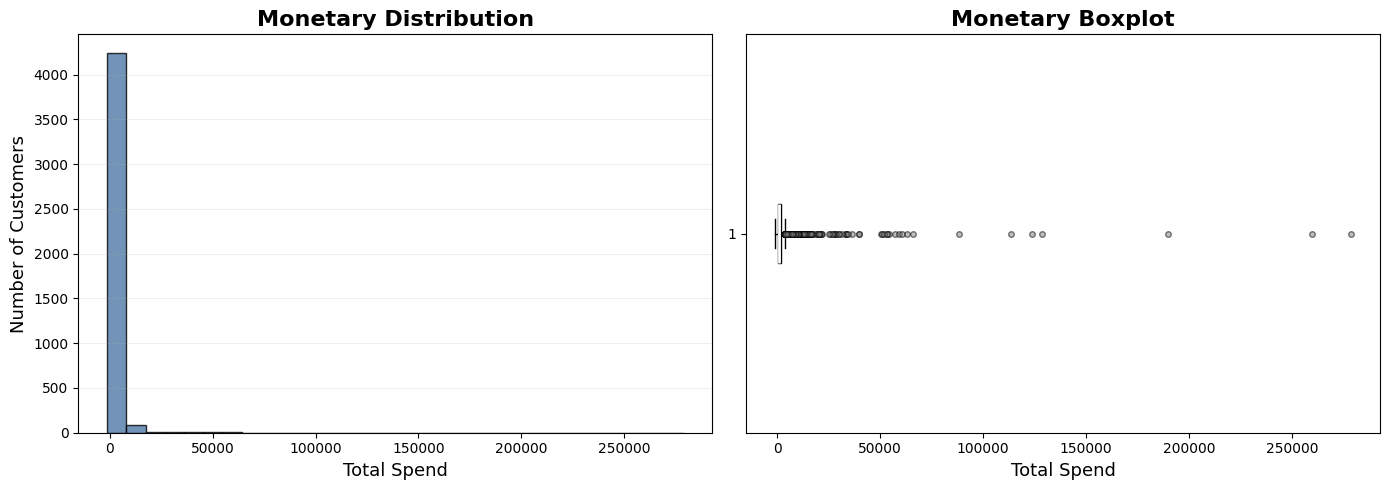

In [42]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax[0].hist(
    customer_data['Total_Spend'],
    bins=30,
    color='#4e79a7',
    edgecolor='black',
    alpha=0.8
)

ax[0].set_title(
    'Monetary Distribution',
    fontsize=16,
    fontweight='bold'
)

ax[0].set_xlabel(
    'Total Spend',
    fontsize=13
)

ax[0].set_ylabel(
    'Number of Customers',
    fontsize=13
)

ax[0].grid(axis='y', alpha=0.2)

# Boxplot
ax[1].boxplot(
    customer_data['Total_Spend'],
    vert=False,
    patch_artist=True,

    boxprops=dict(
        facecolor='#4e79a7',
        color='black'
    ),

    medianprops=dict(
        color='white',
        linewidth=2
    ),

    whiskerprops=dict(
        color='black'
    ),

    capprops=dict(
        color='black'
    ),

    flierprops=dict(
        markerfacecolor='gray',
        marker='o',
        markersize=4,
        alpha=0.5
    )
)

ax[1].set_title(
    'Monetary Boxplot',
    fontsize=16,
    fontweight='bold'
)

ax[1].set_xlabel(
    'Total Spend',
    fontsize=13
)

plt.tight_layout()
plt.show()

# **Product Diversity**

In this step, we are going to understand the diversity in the product purchase behavior of customers. Understanding product diversity can help in crafting personalized marketing strategies and product recommendations. Here, I am going to define the following feature:



*   **Unique Products Purchased**: This feature represents the number of distinct products bought by a customer. A higher value indicates that the customer has a diverse taste or preference, buying a wide range of products, while a lower value might indicate a focused or specific preference. Understanding the diversity in product purchases can help un segmenting customers based on their buying diversity, which can be a critical input in personalizing product recommendations.



In [43]:
# Calculate the number of unique products by each customer
unique_products_purchased = (df.groupby('CustomerID')['StockCode'].nunique().reset_index())
unique_products_purchased.rename(columns = {'StockCode': 'Unique_Products_Purchased'}, inplace = True)

# Merge the new feature into the customer_data dataframe
customer_data = pd.merge(customer_data, unique_products_purchased, on = 'CustomerID')

# Display the first few rows of the customer_data dataframe
customer_data.head()

,CustomerID,DaysSinceLastPurchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased
0,12346.0,325,2,0,0.00,0.000000,1
1,12347.0,2,7,2458,4310.00,615.714286,103
2,12348.0,75,4,2332,1437.24,359.310000,21
3,12349.0,18,1,630,1457.55,1457.550000,72
4,12350.0,310,1,196,294.40,294.400000,16


# **Behavior Features**

In this step, we aim to understand and capture the shopping patterns and behaviors of customers. These features will give us insights into the customers' preferences regarding when they like to shop, which can be crucial information for personalizing their shopping experience. Here are the features I am planning to introduce:



*   **Average Days Between Purchases**: This feature represents the average number of days a customer waits before making another purchase. Understanding this can help in predicting when the customer is likely to make their next purchase, which can be a crucial metric for targeted marketing and personalized promotions.

*   **Favorite Shopping Day**: This denotes the day of the week when the customer shops the most. This information can help in identifying the preferred shopping days of different customer segments, which can be used to optimize marketing strategies and promotions for different days of the week.

*   **Favorite Shopping Hour**: This refers to the hour of the day when the customer shops the most. Identifying the favorite shopping hour can aid in optimizing the timing of marketing campaigns and promotions to align with the times when different customer segments are most active.

By building these behaviors in our dataset, we can create a more rounded view of our customers, which will potentially enhance the effectiveness of the clustering algorithm, leading to more meaningful customer segments.



In [44]:
# Extract day of week and hour from InvoiceDate
df['Day_Of_Week'] = df['InvoiceDate'].dt.dayofweek
df['Hour'] = df['InvoiceDate'].dt.hour

# Calculate the average number of days between consecutive purchases
days_between_purchases = df.groupby('CustomerID')['InvoiceDay'].apply(lambda x: (x.diff().dropna()).apply(lambda y: y.days))
average_days_between_purchases = days_between_purchases.groupby('CustomerID').mean().reset_index()
average_days_between_purchases.rename(columns = {'InvoiceDay': 'Average_Days_Between_Purchases'}, inplace = True)

# Find the favorite shopping day of the week
favorite_shopping_day = df.groupby(['CustomerID','Day_Of_Week']).size().reset_index(name = 'Count')
favorite_shopping_day = favorite_shopping_day.loc[favorite_shopping_day.groupby('CustomerID')['Count'].idxmax()][['CustomerID', 'Day_Of_Week']]

# Find the favorite shopping hour of the day
favorite_shopping_hour = df.groupby(['CustomerID','Hour']).size().reset_index(name = 'Count')
favorite_shopping_hour = favorite_shopping_hour.loc[favorite_shopping_hour.groupby('CustomerID')['Count'].idxmax()][['CustomerID', 'Hour']]

# Merge the new features into the customer_data dataframe
customer_data = pd.merge(customer_data, average_days_between_purchases, on = 'CustomerID')
customer_data = pd.merge(customer_data, favorite_shopping_day, on = 'CustomerID')
customer_data = pd.merge(customer_data, favorite_shopping_hour, on = 'CustomerID')

# Display the first few rows of the customer_data dataframe
customer_data.head()

/tmp/ipykernel_11792/3576726159.py:6: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  days_between_purchases = df.groupby('CustomerID')['InvoiceDay'].apply(lambda x: (x.diff().dropna()).apply(lambda y: y.days))


,CustomerID,DaysSinceLastPurchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Day_Of_Week,Hour
0,12346.0,325,2,0,0.00,0.000000,1,0.000000,1,10
1,12347.0,2,7,2458,4310.00,615.714286,103,2.016575,1,14
2,12348.0,75,4,2332,1437.24,359.310000,21,10.884615,3,19
3,12349.0,18,1,630,1457.55,1457.550000,72,0.000000,0,9
4,12350.0,310,1,196,294.40,294.400000,16,0.000000,2,16


# **Geographic Features**

In this step, will introduce a geographic feature that reflects the grographical location od customers.
Understanding the geographic distribution of customers is pivotal for several reasons:



*   **Country**: This feature identifies the country where each customer is located. Including the country data can help us understand region-specific buying patterns and preferences. Different regions might have varying preferences and purchasing behaviors which can be critical in personalizing marketing strategies and inventory planning. Furthermore, it can be instumental in logistics and supply chain optimization, particularly for an online retailer where shipping and delivery play a significant role.


In [45]:
df['Country'].value_counts(normalize=True).head()

,proportion
Country,
United Kingdom,0.890971
Germany,0.022722
France,0.020402
EIRE,0.018440
Spain,0.006162


# **Inference:**

Given that a substantial (89%) of transactions are originating from the **United Kingdom**, we might consider creating a binary feature indicating whether the transaction is from the UK or not. This approach can potentially streamline the clustering process without losing critical geographical information, especially when considering the application of algorithms like K-means which are sensitive to the dimensionality of the feature space.

# **Methodology:**



*   First, I will group the data by `CustomerID` and `Country` and calculate the number of transactions per country for each customer.

*   Next, I will identify the main country for each customer (the country from which they have the maximum transactions).

*   Then, I will create a binary column indicating whether the customer is from the UK or not.

*   Finally, I will merge this information with the `customer_data` dataframe to include the new feature in our analysis.






In [46]:
# Group by CustomerID and Country to get the number of transactions per country for each customer
customer_country = df.groupby(['CustomerID', 'Country']).size().reset_index(name = 'Number_of_Transactions')

# Get the country with the maximum number of transactions for each customer (in case a customer has transactions with multiple countries)
customer_main_country = customer_country.sort_values('Number_of_Transactions', ascending = False).drop_duplicates('CustomerID')

# Create a binary column indicating whether the customer is from the UK or not
customer_main_country['IS_UK'] = customer_main_country['Country'].apply(lambda x: 1 if x == 'United Kingdom' else 0)

# Merge this data with our customer_data dataframe
customer_data = pd.merge(customer_data, customer_main_country[['CustomerID', 'IS_UK']], on = 'CustomerID', how = 'left')

# Display the first few rows of the customer_data dataframe
customer_data.head()

,CustomerID,DaysSinceLastPurchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Day_Of_Week,Hour,IS_UK
0,12346.0,325,2,0,0.00,0.000000,1,0.000000,1,10,1
1,12347.0,2,7,2458,4310.00,615.714286,103,2.016575,1,14,0
2,12348.0,75,4,2332,1437.24,359.310000,21,10.884615,3,19,0
3,12349.0,18,1,630,1457.55,1457.550000,72,0.000000,0,9,0
4,12350.0,310,1,196,294.40,294.400000,16,0.000000,2,16,0


In [47]:
# Display feature distribution
customer_data['IS_UK'].value_counts()

,count
IS_UK,
1,3866
0,416


# **Cancellation Insights**

In this step, I am going to delve deeper into the cancellation patterns of customers to gain insights that can enhance our customer segmentation model. The features I am planning to introduce are:



*   **Cancellation Frequency**: This metric represents the total number of transactions a customer has cancelled. Understanding the frequency of cancellations can help us identify cusromers who are more likely to cancel transactions. This could be an indicator or dissatisfaction or other issues, and understanding this can help us tailor strategies to reduce cancellations and enhance customer satisfaction.

*   **Cancellation Rate**: This represents the proportion of transactions that a customer has canceled out all their transactions. This metric gives a normalized view of cancellation behavior. A high cancellation rate might be indicative of an unsatisfied customer segment. By identifying these segments, we can develop targeted strategies to improve their shopping experience and potentially reduce the cancellation rate.

By incorporating these cancellation insights into our dataset, we can build a more comprehensive view of customer behavior, which could potentially aid in creating more effective and nuanced customer segmentation.



In [48]:
# Calculate the total number of transactions made by each customer
total_transactions = df.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()

# Cal

In [49]:
df[df['InvoiceNo'].astype(str).str.startswith('C')]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TransactionStatus,InvoiceDay,Total_Spend,Day_Of_Week,Hour
152,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom,Cancelled,2010-12-01,-4.65,2,9
233,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,Cancelled,2010-12-01,-19.80,2,10
234,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,Cancelled,2010-12-01,-6.96,2,10
235,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,Cancelled,2010-12-01,-6.96,2,10
236,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,Cancelled,2010-12-01,-6.96,2,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...
399133,C581490,22178,VICTORIAN GLASS HANGING T-LIGHT,-12,2011-12-09 09:57:00,1.95,14397.0,United Kingdom,Cancelled,2011-12-09,-23.40,4,9
399134,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom,Cancelled,2011-12-09,-9.13,4,9
399382,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom,Cancelled,2011-12-09,-54.75,4,11
399383,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom,Cancelled,2011-12-09,-1.25,4,11
